## investigating the collector environment.


In [24]:
import numpy as np
import torch 

from torch import nn 

from environments.collector.params import EnvParams
from environments.collector.wrappers import CollectorGymEnv

env = CollectorGymEnv(numpy_output= True)

env_params = EnvParams()

import importlib
import agent_sketch_bfs

importlib.reload(agent_sketch_bfs)


<module 'agent_sketch_bfs' from 'c:\\pythonlek\\8sem\\Reinforcement-Learning-\\final_project\\finalproject\\part2\\agent_sketch_bfs.py'>

In [ ]:
from environments.collector.wrappers import CollectorGymEnv

env = CollectorGymEnv(numpy_output=True)
obs, info = env.reset(seed=0)

p0 = obs["player_0"]

tile_map, self_pos, opponent_pos, item_positions = agent_sketch_bfs.get_state_parts(p0)

action = agent_sketch_bfs.bfs_first_action_to_item(
    tile_map,
    self_pos,
    item_positions,
)

action

1

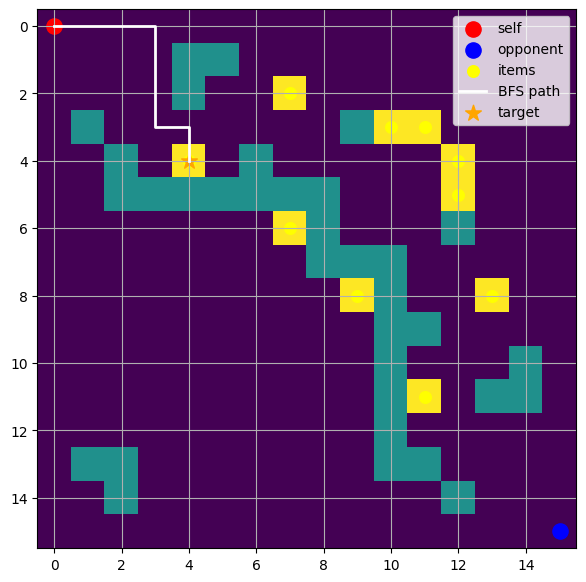

In [25]:
import matplotlib.pyplot as plt
import numpy as np

def plot_bfs_decision(player_obs):
    tile_map, self_pos, opponent_pos, item_positions = agent_sketch_bfs.get_state_parts(player_obs)
    path = agent_sketch_bfs.bfs_path_to_item(tile_map, self_pos, item_positions)

    plt.figure(figsize=(7, 7))
    plt.imshow(tile_map, cmap="viridis")

    sy, sx = self_pos
    oy, ox = opponent_pos
    plt.scatter([sx], [sy], c="red", s=120, label="self")
    plt.scatter([ox], [oy], c="blue", s=120, label="opponent")

    if item_positions:
        ys, xs = zip(*item_positions)
        plt.scatter(xs, ys, c="yellow", s=70, label="items")

    if path:
        py, px = zip(*path)
        plt.plot(px, py, c="white", linewidth=2, label="BFS path")
        plt.scatter([px[-1]], [py[-1]], c="orange", s=140, marker="*", label="target")

    plt.legend()
    plt.grid()
    plt.show()

plot_bfs_decision(obs["player_0"])


## vanilla(no pretraining) dqn 

In [29]:
import importlib
import train_agent

import random

importlib.reload(train_agent)
eval_seed = random.randint(0,100)

result = train_agent.train_dqn({
    "total_steps": 5000,
    "learning_starts": 250,
    "batch_size": 64,
    "target_update_interval": 250,
    "eval_interval": 500,
    "log_interval": 250,
    "eval_seeds": (0,),
}, progress=True)

result["final_evaluation"]


step=250 epsilon=0.984 buffer=250 episodes=1 loss=0.4845 return=nan
step=500 epsilon=0.968 buffer=500 episodes=1 loss=0.0534 return=nan
eval step=500 metric=-55.30 baseline=-76.00 random=-7.00 best=-55.30
step=750 epsilon=0.953 buffer=750 episodes=1 loss=0.0454 return=nan
step=1000 epsilon=0.937 buffer=1000 episodes=1 loss=0.0638 return=-1003.00
eval step=1000 metric=-20.30 baseline=-26.00 random=-7.00 best=-20.30
step=1250 epsilon=0.921 buffer=1250 episodes=2 loss=0.0956 return=-1003.00
step=1500 epsilon=0.905 buffer=1500 episodes=2 loss=0.0799 return=-1003.00
eval step=1500 metric=-23.80 baseline=-31.00 random=-7.00 best=-20.30
step=1750 epsilon=0.889 buffer=1750 episodes=2 loss=0.0786 return=-1003.00
step=2000 epsilon=0.873 buffer=2000 episodes=2 loss=0.0893 return=-987.00
eval step=2000 metric=-16.00 baseline=-19.00 random=-9.00 best=-16.00
step=2250 epsilon=0.858 buffer=2250 episodes=3 loss=0.1144 return=-987.00
step=2500 epsilon=0.842 buffer=2500 episodes=3 loss=0.1129 return=-98

{'primary_metric': -13.899999999999999,
 'baseline_mean_score_diff': -16.0,
 'random_mean_score_diff': -9.0,
 'baseline_matches': [{'seed': 0,
   'steps': 1000,
   'team_points': [1, 17],
   'score_diff': -16,
   'reward_diff': 38.0}],
 'random_matches': [{'seed': 0,
   'steps': 1000,
   'team_points': [0, 9],
   'score_diff': -9,
   'reward_diff': 198.0}]}

In [20]:
import pandas as pd

history = pd.DataFrame(result["history"])
history


,type,step,epsilon,buffer_size,episodes,mean_loss,mean_episode_return,saved_best,primary_metric,baseline_mean_score_diff,random_mean_score_diff,baseline_matches,random_matches
0,train,250,0.984167,250.0,1.0,0.484530,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,train,500,0.968333,500.0,1.0,0.053436,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,eval,500,NaN,NaN,NaN,NaN,NaN,True,-55.3,-76.0,-7.0,"[{'seed': 0, 'steps': 1000, 'team_points': [1,...","[{'seed': 0, 'steps': 1000, 'team_points': [1,..."
3,train,750,0.952500,750.0,1.0,0.045357,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,train,1000,0.936667,1000.0,1.0,0.063803,-1003.000000,NaN,NaN,NaN,NaN,NaN,NaN
5,eval,1000,NaN,NaN,NaN,NaN,NaN,True,-20.3,-26.0,-7.0,"[{'seed': 0, 'steps': 1000, 'team_points': [7,...","[{'seed': 0, 'steps': 1000, 'team_points': [2,..."
6,train,1250,0.920833,1250.0,2.0,0.095588,-1003.000000,NaN,NaN,NaN,NaN,NaN,NaN
7,train,1500,0.905000,1500.0,2.0,0.079871,-1003.000000,NaN,NaN,NaN,NaN,NaN,NaN
8,eval,1500,NaN,NaN,NaN,NaN,NaN,False,-23.8,-31.0,-7.0,"[{'seed': 0, 'steps': 1000, 'team_points': [9,...","[{'seed': 0, 'steps': 1000, 'team_points': [3,..."
9,train,1750,0.889167,1750.0,2.0,0.078606,-1003.000000,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='step'>

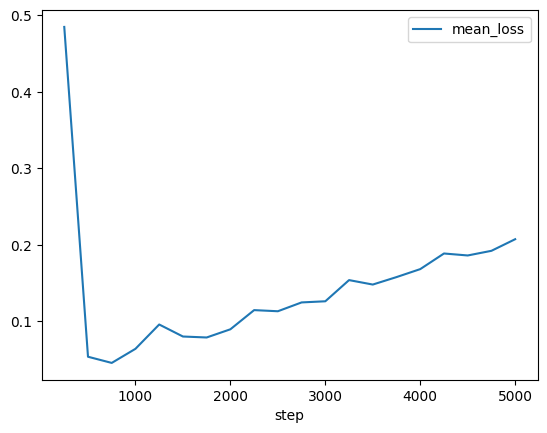

In [21]:
train_rows = history[history["type"] == "train"]
train_rows.plot(x="step", y="mean_loss")


<Axes: xlabel='step'>

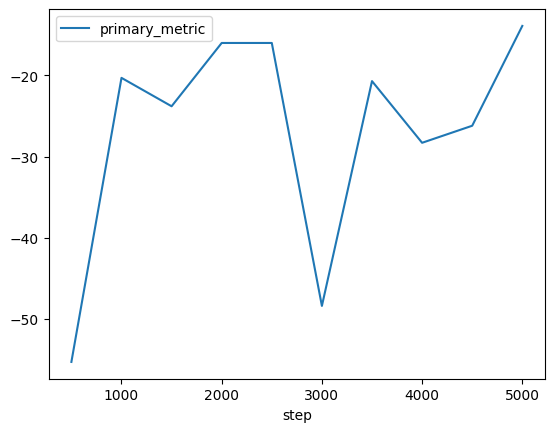

In [22]:
eval_rows = history[history["type"] == "eval"]
eval_rows.plot(x="step", y="primary_metric")


In [23]:
eval_result, checkpoint = train_agent.evaluate_checkpoint(
    result["latest_checkpoint_path"],
    eval_seeds=(0, 1, 2),
)

eval_result


{'primary_metric': -25.099999999999998,
 'baseline_mean_score_diff': -33.0,
 'random_mean_score_diff': -6.666666666666667,
 'baseline_matches': [{'seed': 0,
   'steps': 1000,
   'team_points': [1, 17],
   'score_diff': -16,
   'reward_diff': 38.0},
  {'seed': 1,
   'steps': 1000,
   'team_points': [3, 55],
   'score_diff': -52,
   'reward_diff': 66.0},
  {'seed': 2,
   'steps': 1000,
   'team_points': [9, 40],
   'score_diff': -31,
   'reward_diff': 73.0}],
 'random_matches': [{'seed': 0,
   'steps': 1000,
   'team_points': [0, 9],
   'score_diff': -9,
   'reward_diff': 198.0},
  {'seed': 1,
   'steps': 1000,
   'team_points': [2, 9],
   'score_diff': -7,
   'reward_diff': 237.0},
  {'seed': 2,
   'steps': 1000,
   'team_points': [3, 7],
   'score_diff': -4,
   'reward_diff': 240.0}]}

## attempting to better dqn with samples from bfs_agent 

In [59]:
# run before code under to fetch newest changes to train_agent, agent_sketch_dqn etc 

import importlib
import agent_sketch_dqn
import train_agent

importlib.reload(agent_sketch_dqn)
importlib.reload(train_agent)

<module 'train_agent' from 'c:\\pythonlek\\8sem\\Reinforcement-Learning-\\final_project\\finalproject\\part2\\train_agent.py'>

In [60]:
bfs_pretrain = train_agent.pretrain_from_bfs(
    num_steps=25_000,
    epochs=10,
    batch_size=64,
    learning_rate=1e-3,
    seed=0,
    opponent="random",
    progress=True,
)

result = train_agent.train_dqn(
    {
        "total_steps": 30_000,
        "learning_starts": 2_000,
        "batch_size": 64, # always on the form 2^n
        "learning_rate": 1e-4,
        "epsilon_start": 0.15,
        "epsilon_end": 0.02,
        "epsilon_decay_steps": 15_000,
        "target_update_interval": 2000,
        "eval_interval": 5_000,
        "log_interval": 500,
        "eval_seeds": (0, 1, 2),
        "opponent_mix": (("random", 1.0),),
    },
    progress=True,
    initial_state_dict=bfs_pretrain["state_dict"],
)


bc epoch=1 loss=0.1305 accuracy=0.954
bc epoch=2 loss=0.0158 accuracy=0.995
bc epoch=3 loss=0.0101 accuracy=0.996
bc epoch=4 loss=0.0086 accuracy=0.997
bc epoch=5 loss=0.0069 accuracy=0.997
bc epoch=6 loss=0.0084 accuracy=0.996
bc epoch=7 loss=0.0074 accuracy=0.997
bc epoch=8 loss=0.0068 accuracy=0.997
bc epoch=9 loss=0.0073 accuracy=0.998
bc epoch=10 loss=0.0064 accuracy=0.997
step=500 epsilon=0.146 buffer=500 episodes=1 loss=nan return=nan
step=1000 epsilon=0.141 buffer=1000 episodes=1 loss=nan return=2153.00
step=1500 epsilon=0.137 buffer=1500 episodes=2 loss=nan return=2153.00
step=2000 epsilon=0.133 buffer=2000 episodes=2 loss=15.1528 return=1985.50
step=2500 epsilon=0.128 buffer=2500 episodes=3 loss=11.6682 return=1985.50
step=3000 epsilon=0.124 buffer=3000 episodes=3 loss=10.4491 return=2082.67
step=3500 epsilon=0.120 buffer=3500 episodes=4 loss=9.4961 return=2082.67
step=4000 epsilon=0.115 buffer=4000 episodes=4 loss=8.9404 return=2043.25
step=4500 epsilon=0.111 buffer=4500 epi

### eval_last_training_run

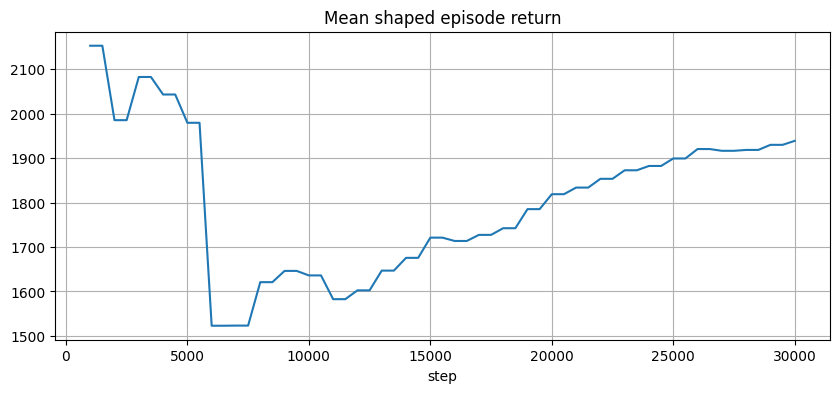

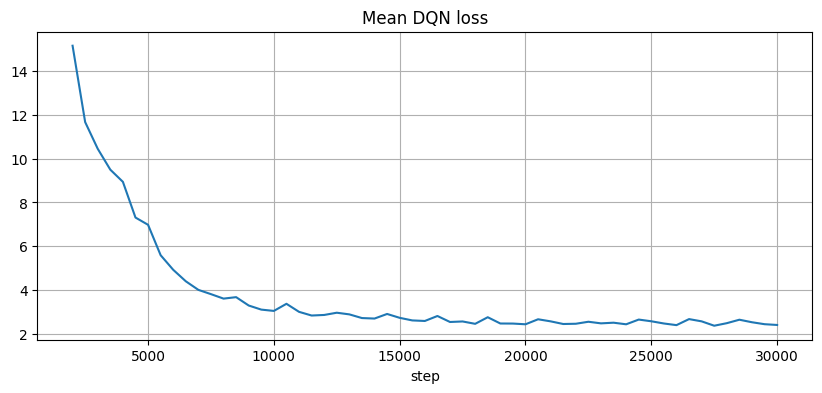

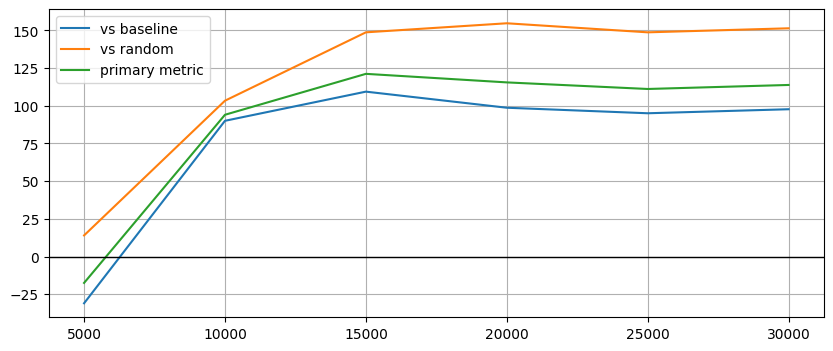

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

hist = pd.DataFrame(result["history"])

train_hist = hist[hist["type"] == "train"]
eval_hist = hist[hist["type"] == "eval"]

plt.figure(figsize=(10, 4))
plt.plot(train_hist["step"], train_hist["mean_episode_return"])
plt.title("Mean shaped episode return")
plt.xlabel("step")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(train_hist["step"], train_hist["mean_loss"])
plt.title("Mean DQN loss")
plt.xlabel("step")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(eval_hist["step"], eval_hist["baseline_mean_score_diff"], label="vs baseline")
plt.plot(eval_hist["step"], eval_hist["random_mean_score_diff"], label="vs random")
plt.plot(eval_hist["step"], eval_hist["primary_metric"], label="primary metric")
plt.axhline(0, color="black", linewidth=1)
plt.legend()
plt.grid(True)
plt.show()


### sim last checkpoint vs bfs 

In [62]:
import importlib
import train_agent

importlib.reload(train_agent)

eval_bfs, checkpoint = train_agent.evaluate_checkpoint_vs_bfs(
    train_agent.LATEST_CHECKPOINT_PATH,
    seeds=(0, 1, 2),
)

eval_bfs


{'mean_score_diff': -3.6666666666666665,
 'mean_reward_diff': -3.6666666666666665,
 'matches': [{'seed': 0,
   'steps': 1000,
   'team_points': [125, 128],
   'score_diff': -3,
   'reward_diff': -3.0},
  {'seed': 1,
   'steps': 1000,
   'team_points': [123, 127],
   'score_diff': -4,
   'reward_diff': -4.0},
  {'seed': 2,
   'steps': 1000,
   'team_points': [135, 139],
   'score_diff': -4,
   'reward_diff': -4.0}]}